# Laptop Price Prediction

In [1]:
import math
import re
import pandas as pd

In [2]:
df=pd.read_csv("laptop_data.csv",index_col=0)

# Data Exploration Analysis

In [3]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   str    
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   str    
 10  Price             1303 non-null   float64
dtypes: float64(2), str(9)
memory usage: 250.8 KB


In [5]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [6]:
df.describe()

,Inches,Price
count,1303.000000,1303.000000
mean,15.017191,59870.042910
std,1.426304,37243.201786
min,10.100000,9270.720000
25%,14.000000,31914.720000
50%,15.600000,52054.560000
75%,15.600000,79274.246400
max,18.400000,324954.720000


In [7]:
df.corr(numeric_only=True)

,Inches,Price
Inches,1.000000,0.068197
Price,0.068197,1.000000


In [8]:
df["Company"].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [9]:
df.ScreenResolution.value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

# Feature Engineering

In [10]:
def extract_resolution(resolution_string):
    match= re.search(r"(\d+x\d+)",resolution_string)
    return match.group(1) if match else None

df["Resolution"]=df["ScreenResolution"].apply(extract_resolution)


In [11]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600


In [12]:
def extract_ghz(GHz):
    match=re.search(r"(\d+(\.\d+)?)GHz",GHz)
    return float(match.group(1)) if match else None

df["GHz"]=df["Cpu"].apply(extract_ghz)    

In [13]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,GHz
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.3
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.8
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.1


In [14]:
df.Ram.value_counts()

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

In [15]:
df["Ram"]=df["Ram"].str.replace("GB","").astype("int32")

In [16]:
df.Memory.value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

In [17]:
df["Memory"]=df["Memory"].str.replace("2TB","2048GB")
df["Memory"]=df["Memory"].str.replace("1.0TB","1024GB")
df["Memory"]=df["Memory"].str.replace("1TB","1024GB")

In [18]:
df.Memory.value_counts()

Memory
256GB SSD                           412
1024GB HDD                          224
500GB HDD                           132
512GB SSD                           118
128GB SSD +  1024GB HDD              94
128GB SSD                            76
256GB SSD +  1024GB HDD              73
32GB Flash Storage                   38
2048GB HDD                           16
64GB Flash Storage                   15
512GB SSD +  1024GB HDD              14
1024GB SSD                           14
256GB SSD +  2048GB HDD              10
1024GB Hybrid                         9
256GB Flash Storage                   8
16GB Flash Storage                    7
32GB SSD                              6
180GB SSD                             5
128GB Flash Storage                   4
16GB SSD                              3
512GB SSD +  2048GB HDD               3
256GB SSD +  256GB SSD                2
256GB SSD +  500GB HDD                2
128GB SSD +  2048GB HDD               2
1024GB SSD +  1024GB HDD         

In [19]:
df["SSD"]=0
df["HDD"]=0
df["Flash_Storage"]=0
df["Hybrid"]=0

In [20]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Resolution          0
GHz                 0
SSD                 0
HDD                 0
Flash_Storage       0
Hybrid              0
dtype: int64

In [21]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,GHz,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.3,0,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.8,0,0,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.5,0,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.7,0,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.1,0,0,0,0


In [22]:
df['Memory']=df['Memory'].str.replace("256GB SSD +  256GB SSD","512GB SSD")
df['Memory']=df['Memory'].str.replace("512GB SSD +  256GB SSD","768GB SSD")
df['Memory']=df['Memory'].str.replace("512GB SSD +  512GB SSD","1024GB SSD")
df['Memory']=df['Memory'].str.replace("1024GB HDD +  1024GB HDD","2048GB HDD")

In [23]:
df.Memory.value_counts()

Memory
256GB SSD                           412
1024GB HDD                          224
500GB HDD                           132
512GB SSD                           120
128GB SSD +  1024GB HDD              94
128GB SSD                            76
256GB SSD +  1024GB HDD              73
32GB Flash Storage                   38
2048GB HDD                           17
64GB Flash Storage                   15
1024GB SSD                           15
512GB SSD +  1024GB HDD              14
256GB SSD +  2048GB HDD              10
1024GB Hybrid                         9
256GB Flash Storage                   8
16GB Flash Storage                    7
32GB SSD                              6
180GB SSD                             5
128GB Flash Storage                   4
16GB SSD                              3
512GB SSD +  2048GB HDD               3
256GB SSD +  500GB HDD                2
128GB SSD +  2048GB HDD               2
1024GB SSD +  1024GB HDD              2
512GB Flash Storage              

In [24]:
def extract_memory_size(memory_string):
    if "SSD" in memory_string:
        size_match=re.search(r"\b(\d+)GB\s+SSD\b",memory_string)
        if size_match:
            df.loc[df["Memory"] == memory_string, "SSD"] = int(size_match.group(1))
    if "HDD" in memory_string:
        size_match=re.search(r"\b(\d+)GB\s+HDD\b",memory_string)
        if size_match:
            df.loc[df["Memory"]==memory_string, "HDD"]=int(size_match.group(1))

    if "Flash Storage" in memory_string:
        size_match=re.search(r"\b(\d+)GB\s+Flash Storage\b",memory_string)
        if size_match:
            df.loc[df["Memory"]==memory_string, "Flash_Storage"]=int(size_match.group(1))

    if "Hybrid" in memory_string:
        size_match=re.search(r"\b(\d+)GB\s+Hybrid\b",memory_string)
        if size_match:
            df.loc[df["Memory"]==memory_string, "Hybrid"]=int(size_match.group(1))
    

for memory in df["Memory"]:
    extract_memory_size(memory)

In [25]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Resolution          0
GHz                 0
SSD                 0
HDD                 0
Flash_Storage       0
Hybrid              0
dtype: int64

In [26]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,GHz,SSD,HDD,Flash_Storage,Hybrid
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,2.3,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,1.8,0,0,128,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,2.5,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,2.7,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,3.1,256,0,0,0


In [27]:
df['SSD']=df['SSD'].astype('int32')
df['HDD']=df['HDD'].astype('int32')
df['Flash_Storage']=df['Flash_Storage'].astype('int32')
df['Hybrid']=df['Hybrid'].astype('int32')

In [28]:
abs(df.corr(numeric_only=True)["Price"]).sort_values(ascending=False)

Price            1.000000
Ram              0.743007
SSD              0.670682
GHz              0.430293
HDD              0.094856
Inches           0.068197
Flash_Storage    0.040511
Hybrid           0.008011
Name: Price, dtype: float64

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   str    
 10  Price             1303 non-null   float64
 11  Resolution        1303 non-null   str    
 12  GHz               1303 non-null   float64
 13  SSD               1303 non-null   int32  
 14  HDD               1303 non-null   int32  
 15  Flash_Storage     1303 non-null   int32  
 16  Hybrid            1303 non-null   int32  
dtypes: flo

In [30]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Resolution          0
GHz                 0
SSD                 0
HDD                 0
Flash_Storage       0
Hybrid              0
dtype: int64

In [31]:
df.OpSys.value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [32]:
df["OpSys"] = df["OpSys"].replace("Windows 10 S","Windows 10")

In [33]:
df["OpSys"] = df["OpSys"].replace("Mac OS X","macOS")

In [34]:
df["Weight"]=df["Weight"].str.rstrip("kg").astype(float)

In [35]:
def calculate_ppi(resolution,diognal):
    width,height=map(int,resolution.split("x"))
    diognal_pixels=math.sqrt(width**2 + height**2)
    ppi=diognal_pixels / diognal
    return ppi
df["PPI"]=df.apply(lambda row : calculate_ppi(row["Resolution"],row["Inches"]),axis=1)

In [36]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
Resolution          0
GHz                 0
SSD                 0
HDD                 0
Flash_Storage       0
Hybrid              0
PPI                 0
dtype: int64

In [37]:
abs(df.corr(numeric_only=True)["Price"]).sort_values(ascending=False)

Price            1.000000
Ram              0.743007
SSD              0.670682
PPI              0.473487
GHz              0.430293
Weight           0.210370
HDD              0.094856
Inches           0.068197
Flash_Storage    0.040511
Hybrid           0.008011
Name: Price, dtype: float64

In [38]:
df["IPS"] = df["ScreenResolution"].apply(lambda x:1 if "IPS" in x else 0)
df["TouchScreen"]=df["ScreenResolution"].apply(lambda x:1 if "TouchScreen" in x else 0)

In [39]:
df_model = pd.get_dummies(
    df.drop(columns=["ScreenResolution","Cpu","Gpu","Memory","Resolution"]),
    drop_first=True,
    dtype=int,
)

In [40]:
x=df_model.drop(columns=["Price"])
y=df_model["Price"]

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [42]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.823328,15960.553322,10538.593311
XGBRegressor,0.810116,16546.598270,9823.943354
Linear,0.768562,18267.620660,13027.743367
Lasso,0.768546,18268.250312,13020.268241
Ridge,0.759548,18619.946291,13300.852480
SGD,0.753138,18866.507857,13579.708725
Decision Tree,0.741116,19320.445232,12983.878731
Extra Tree,0.698243,20858.987143,12299.132745
KNeighborsRegressor,0.646539,22575.405964,18537.896437
AdaBoost,0.605184,23859.536101,14553.185810


In [44]:
abs(df_model.corr(numeric_only=True)["Price"]).sort_values(ascending=False)

Price                   1.000000
Ram                     0.743007
SSD                     0.670682
TypeName_Notebook       0.549248
PPI                     0.473487
GHz                     0.430293
TypeName_Gaming         0.375789
TypeName_Ultrabook      0.255658
IPS                     0.252208
TypeName_Workstation    0.249752
Company_Razer           0.233756
Weight                  0.210370
Company_MSI             0.180100
OpSys_No OS             0.177094
OpSys_Linux             0.162060
OpSys_Windows 7         0.152381
OpSys_Windows 10        0.142765
OpSys_Chrome OS         0.118684
TypeName_Netbook        0.097572
HDD                     0.094856
Company_Mediacom        0.087161
Company_Apple           0.080688
OpSys_macOS             0.080688
Company_Vero            0.071972
Inches                  0.068197
Company_LG              0.067053
Company_Chuwi           0.055646
Company_Dell            0.048509
Company_Microsoft       0.047562
Company_HP              0.041291
Flash_Stor

# Data Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

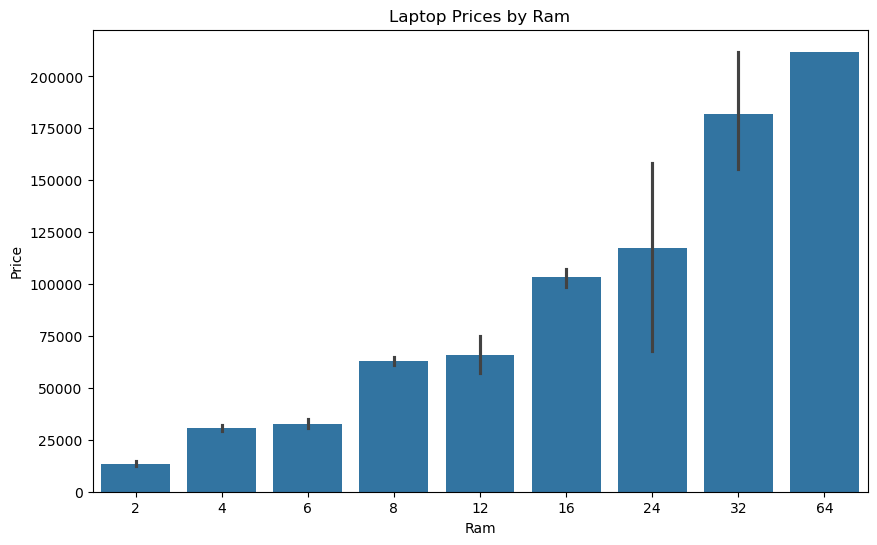

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(x="Ram",y="Price",data=df)
plt.title("Laptop Prices by Ram")
plt.show